Descargas de Librerias necesarias


In [4]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.6 MB 12.2 MB/s eta 0:00:01
   -------------- ------------------------- 4.7/12.6 MB 11.9 MB/s eta 0:00:01
   ----------------------- ---------------- 7.3/12.6 MB 11.9 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.6 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 11.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
qiskit-ibm-runtime 0.23.0 requires qiskit>=1.0.0, which is not installed.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Preparación de Datos

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga
df = pd.read_csv('heart.csv')

# --- PASO 1: BINARIZACIÓN (Manejo de Texto) ---
# Si la columna tiene 'Presence'/'Absence' o texto similar:
target_col = 'Heart Disease'

# Convertimos a 1 si es algo distinto a 'Absence' o si es > 0
if df[target_col].dtype == object:
    df['y_bin'] = df[target_col].apply(lambda x: 1 if 'pres' in str(x).lower() else 0)
else:
    df['y_bin'] = (df[target_col] > 0).astype(int)

# --- PASO 2: SELECCIÓN DE FEATURES (Nombres exactos de TU archivo) ---
# He mapeado los nombres que salieron en tu error
features = [
    'Age', 
    'Cholesterol', 
    'BP', 
    'Max HR', 
    'ST depression', 
    'Number of vessels fluro'
]

X = df[features].values
y = df['y_bin'].values

# --- PASO 3: NORMALIZACIÓN (Z-score) ---
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std

# Split 70/30 manual
m = X_norm.shape[0]
indices = np.random.permutation(m)
train_size = int(0.7 * m)

X_train, y_train = X_norm[indices[:train_size]], y[indices[:train_size]]
X_test, y_test = X_norm[indices[train_size:]], y[indices[train_size:]]

print(f"Dataset listo:")
print(f"Features seleccionadas: {features}")
print(f"Registros entrenamiento: {len(X_train)}, Test: {len(X_test)}")

Dataset listo:
Features seleccionadas: ['Age', 'Cholesterol', 'BP', 'Max HR', 'ST depression', 'Number of vessels fluro']
Registros entrenamiento: 189, Test: 81


2. Entrenamiento (Usando tus funciones de clase)

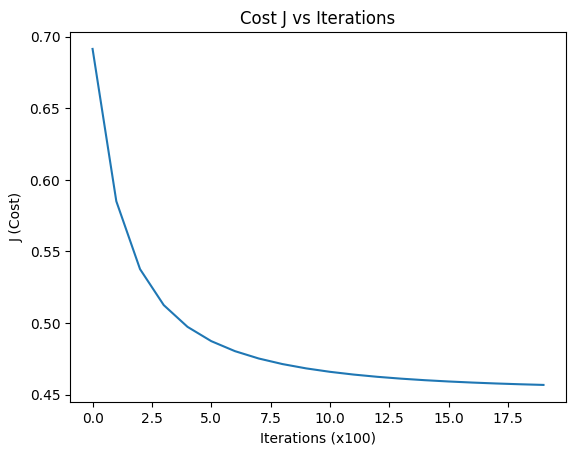

In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost_reg(X, y, w, b, lambda_=0.1):
    m = X.shape[0]
    f_wb = sigmoid(np.dot(X, w) + b)
    # Loss + Regularización L2 (de tu notebook de la hora 2)
    cost = - (1/m) * np.sum(y * np.log(f_wb + 1e-15) + (1-y) * np.log(1-f_wb + 1e-15))
    reg_cost = (lambda_ / (2 * m)) * np.sum(np.square(w))
    return cost + reg_cost

def compute_gradient_reg(X, y, w, b, lambda_=0.1):
    m, n = X.shape
    f_wb = sigmoid(np.dot(X, w) + b)
    err = f_wb - y
    dj_dw = (1/m) * np.dot(X.T, err) + (lambda_ / m) * w
    dj_db = (1/m) * np.sum(err)
    return dj_dw, dj_db

def gradient_descent(X, y, alpha, iters, lambda_):
    w = np.zeros(X.shape[1])
    b = 0.
    J_history = []
    for i in range(iters):
        dj_dw, dj_db = compute_gradient_reg(X, y, w, b, lambda_)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        if i % 100 == 0:
            J_history.append(compute_cost_reg(X, y, w, b, lambda_))
    return w, b, J_history

# Entrenar modelo
w_final, b_final, cost_hist = gradient_descent(X_train, y_train, 0.01, 2000, 0.1)

# Visualizar convergencia
plt.plot(cost_hist)
plt.title("Cost J vs Iterations")
plt.ylabel("J (Cost)")
plt.xlabel("Iterations (x100)")
plt.show()